<a href="https://colab.research.google.com/github/naumankhokhar/sp500-ml-clustering-portfolio-optimization/blob/Ahmad-Butt/Data_Warehouse_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install yahoofinancials

import pandas as pd
import numpy as np
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

[**********************87%*****************      ]  437 of 503 completed

[**********************93%********************   ]  469 of 503 completed

In [33]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

sp500 = tables[0]

tickers = sp500['Symbol'].tolist()

print(tickers[:10])

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


/tmp/ipykernel_2518/74144951.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [27]:
data = yf.download(tickers, start="2022-01-01", end="2025-01-01")['Close']
tickers = tickers[:100]

print(data.shape)
data.head()

/tmp/ipykernel_2518/2773819217.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')


(753, 100)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,CVNA,GOOG,GOOGL,LNT,MMM,MO,SCHW,T,TECH,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702179,178.103683,114.894051,172.679993,127.545784,42.362530,380.485229,564.369995,164.526443,60.037262,...,239.630005,143.893143,143.802979,52.850292,126.958267,34.334213,80.916367,14.767212,119.623711,164.029999
2022-01-04,146.573685,175.843231,114.673462,170.800003,124.546143,42.914051,377.766296,554.000000,163.040482,61.151527,...,220.940002,143.240509,143.215836,52.737385,128.736847,35.092899,84.879150,14.889162,114.775398,156.330002
2022-01-05,144.062744,171.165833,115.275826,162.250000,123.986588,42.410072,371.113525,514.429993,160.523605,60.673992,...,198.000000,136.532593,136.645615,53.206375,128.208237,34.813751,84.265862,15.220166,106.611496,143.490005
2022-01-06,144.566864,168.308472,114.732834,159.750000,123.968246,42.657307,353.192322,514.119995,161.034439,61.213425,...,191.380005,136.430939,136.618332,52.989250,127.143944,35.221729,85.615082,15.162094,104.603004,144.660004
2022-01-07,140.718079,168.474869,114.435890,166.050003,124.353500,42.856995,346.418091,510.700012,156.808624,61.735165,...,184.710007,135.888855,135.893845,52.971882,128.536835,35.622547,86.558617,15.680079,101.841660,141.539993


In [28]:
data = data.dropna(axis=1, thresh=int(0.7 * len(data)))
data = data.ffill().bfill()

print("Cleaned shape:", data.shape)

Cleaned shape: (753, 98)


In [29]:
returns = data.pct_change().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,CVNA,GOOG,GOOGL,LNT,MMM,MO,SCHW,T,TECH,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012692,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018560,...,-0.077995,-0.004536,-0.004083,-0.002136,0.014009,0.022097,0.048974,0.008258,-0.040530,-0.046943
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.103829,-0.046830,-0.045876,0.008893,-0.004106,-0.007955,-0.007225,0.022231,-0.071129,-0.082134
2022-01-06,0.003499,-0.016694,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,-0.033434,-0.000745,-0.000200,-0.004081,-0.008301,0.011719,0.016011,-0.003815,-0.018839,0.008154
2022-01-07,-0.026623,0.000989,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008523,...,-0.034852,-0.003973,-0.005303,-0.000328,0.010955,0.011380,0.011021,0.034163,-0.026398,-0.021568
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009240,0.001719,...,-0.006876,0.011456,0.012060,-0.005903,-0.014115,0.015471,-0.000981,0.006466,0.030076,0.020772


In [30]:
sp500_index = yf.download("^GSPC", start="2022-01-01", end="2025-01-01")['Close']
sp500_returns = sp500_index.pct_change().dropna()

/tmp/ipykernel_2518/161221304.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_index = yf.download("^GSPC", start="2022-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


In [31]:
returns, sp500_returns = returns.align(sp500_returns, join='inner', axis=0)

In [35]:
betas = {}

returns_clean = returns.dropna()
sp500_clean = sp500_returns.dropna()

returns_clean, sp500_clean = returns_clean.align(
    sp500_clean,
    join="inner",
    axis=0
)

market = sp500_clean.squeeze().values

for stock in returns_clean.columns:

    stock_data = returns_clean[stock].squeeze().values

    stock_data = np.array(stock_data)
    market_data = np.array(market)

    mask = (~np.isnan(stock_data)) & (~np.isnan(market_data))

    x = stock_data[mask]
    y = market_data[mask]

    if len(x) < 2:
        betas[stock] = np.nan
        continue

    cov_matrix = np.cov(x, y)

    cov = cov_matrix[0, 1]
    var = np.var(y)

    betas[stock] = cov / var if var != 0 else np.nan

betas = pd.Series(betas).sort_values(ascending=False)

betas.head()

,0
CVNA,3.298454
XYZ,2.548173
APP,2.264945
AMD,2.067498
CCL,1.965284


In [36]:
volatility = returns.std() * np.sqrt(252)
volatility.head()

,0
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839


In [37]:
metrics = pd.DataFrame({
    'Return': returns.mean(),
    'Beta': betas,
    'Volatility': volatility
})

metrics = metrics.dropna()
metrics.head()

,Return,Beta,Volatility
A,-0.000002,1.026165,0.296259
AAPL,0.000591,1.212301,0.270935
ABBV,0.000610,0.299496,0.219958
ABNB,0.000074,1.668475,0.467875
ABT,-0.000106,0.673211,0.217839


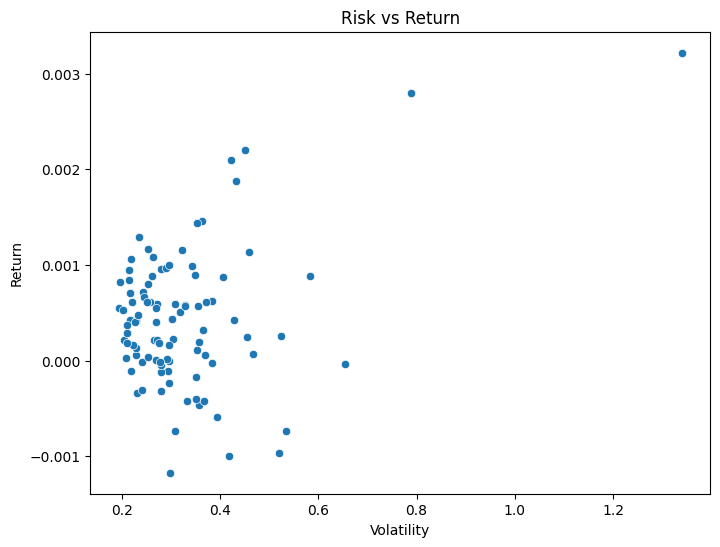

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Volatility', y='Return', data=metrics)
plt.title("Risk vs Return")
plt.show()

In [39]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(metrics)

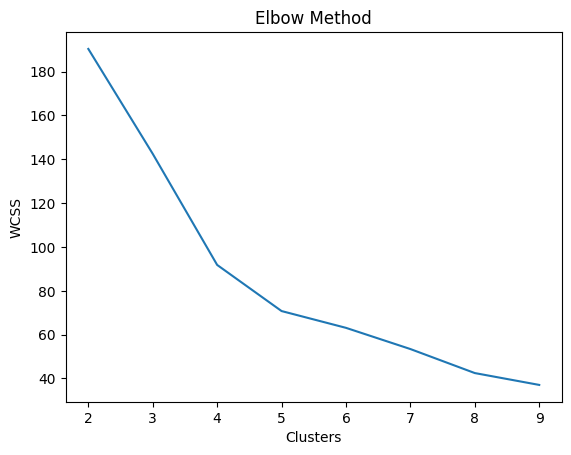

In [40]:
wcss = []

for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42)
metrics['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

In [42]:
agg = AgglomerativeClustering(n_clusters=4)
metrics['Agg_Cluster'] = agg.fit_predict(scaled_data)

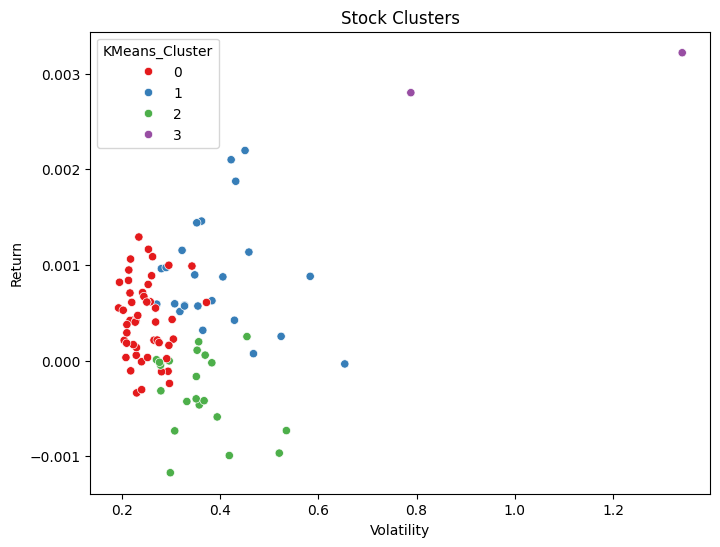

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Volatility',
    y='Return',
    hue='KMeans_Cluster',
    data=metrics,
    palette='Set1'
)
plt.title("Stock Clusters")
plt.show()

In [44]:
metrics.groupby('KMeans_Cluster').mean()

,Return,Beta,Volatility,Agg_Cluster
KMeans_Cluster,,,,
0,0.000430,0.647754,0.247802,0.117647
1,0.000877,1.509315,0.393213,2.208333
2,-0.000325,1.088677,0.359592,0.904762
3,0.003011,2.781700,1.064707,1.000000
